## Running Sentiment Analysis on Your Data

Now that we've got a basic idea of how these two sentiment analysis methods work, you can try them out on your own data.

In the code blocks and sections below, we've provided the code to test your content set with both AFINN and VADER. After running once, you could then adjust variables and see what happens - for example, try changing the threshold for what determines a document as neutral vs positive vs negative, and see how that affects your outcomes.

If the files [name of the files] are not in your JupyterHub environment, use the [gitpuller link] to import the files. 

Some parts of the codes are missing. Replace __ with the correct code. **HINT**: Refer to the lab for help.

In [1]:
# Import necessary libraries
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
from math import ceil
!pip install afinn
from afinn import Afinn 
!pip install vaderSentiment
import vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [2]:
#----------------#
directory = 'Clean_SiR1796-1800' # the name of the data folder containing the documents
# If you wish to use other files, make sure to change the directory to reflect that
#----------------#


documents = [] # create an empty list to track documents with
for doc in os.scandir(directory): # goes into the folder with the name we gave above, and go through each filename it finds
    if not doc.name.startswith('.'): # ignores hidden files like '.ipynb_checkpoints' that are created by JupyterHub
        documents.append(doc.name) # adds that name to the list

If you're getting an error above, check that your directory name is correct, and that you've changed it to the correct name of your folder.

### AFINN

In [3]:
# instantiating the tool
afn = Afinn()

In [4]:
# creating lists to track the total score, number of scored tokens, and document score for each document
total_scores = []
num_scored = []
doc_scores = []

for doc in documents: # go through each document in the list we made in the last code block
    token_scores = []

    filename = str(directory + '/' + doc)
    
    # lets us access the actual text inside the file
    with open(filename) as f:
        # gets all of the text from the file and brings it over so we can work with it
        contents = f.read() 
        # dividing the text into "words" (tokens, really, as we're splitting wherever there is whitespace)
        bag_o_words = contents.split() 

        for word in bag_o_words:
            # score the word
            score = afn.score(word) 
            # if the score isn't 0 (if 0, then the token wasn't scored)
            if score != 0: 
                # add the score to the score list
                token_scores.append(score) 

        # add all the scores together
        total_scores.append(sum(token_scores))
        # find how many words there are in the list (which are the scored words)
        num_scored.append(len(token_scores)) 
        
        # so we don't end up dividing by 0
        if len(token_scores) == 0: 
            doc_scores.append(0)
        # if we scored more than 0 tokens
        else: 
            # get the document score using the Lab's method
            # we also round to three decimal points
            doc_scores.append(round(sum(token_scores) / len(token_scores), 3)) 


#----------------#
# Create the labels based on the scores
#----------------#
labels = []
for score in doc_scores:
    if score > 1:
        labels.append('Positive')
    elif score < -1:
        labels.append('Negative')
    else:
        labels.append('Neutral')

#----------------#
# creating the table
#----------------#

# combining all lists
table_data = list(zip(documents, total_scores, num_scored, doc_scores, labels)) 
# making the table with column titles
student_afinn_df = pd.DataFrame(table_data, columns=['File', 'Total Score', 
                                                     'Num Scored Tokens', 'Doc Score', 'Label'])
student_afinn_df # displaying the table

,File,Total Score,Num Scored Tokens,Doc Score,Label
0,Walter_and_William.__CW0115639198.txt,-66.0,72,-0.917,Neutral
1,"Tom_Tough;_or,_yo_he_CW0117136907.txt",15.0,16,0.938,Neutral
2,Tom_Tackle._Sung_by__CB0130523325.txt,6.0,24,0.250,Neutral
3,The_waggoner._Sung_b_CW0117136903.txt,-3.0,9,-0.333,Neutral
4,The_valiant_dragoo'n_CW0116745543.txt,-8.0,16,-0.500,Neutral
...,...,...,...,...,...
69,"A_New_song,_called_t_CB0130523365.txt",-14.0,23,-0.609,Neutral
70,A_New_ballad._The_bo_CB0127690334.txt,18.0,6,3.000,Positive
71,"A_Loyal_song,_CB0130523337.txt",30.0,22,1.364,Positive
72,A_Collection_of_Engl_CB0129583847.txt,1826.0,2219,0.823,Neutral


In [5]:
# because pandas only shows the first and last 5 rows of a table
# the code below helps us get a better understanding of the distribution of sentiment labels

print("Sentiment Label Counts")
# get a list of unique values for that column and the number of times each appeared
print(student_afinn_df['Label'].value_counts()) 

Sentiment Label Counts
Label
Neutral     55
Positive    17
Negative     2
Name: count, dtype: int64


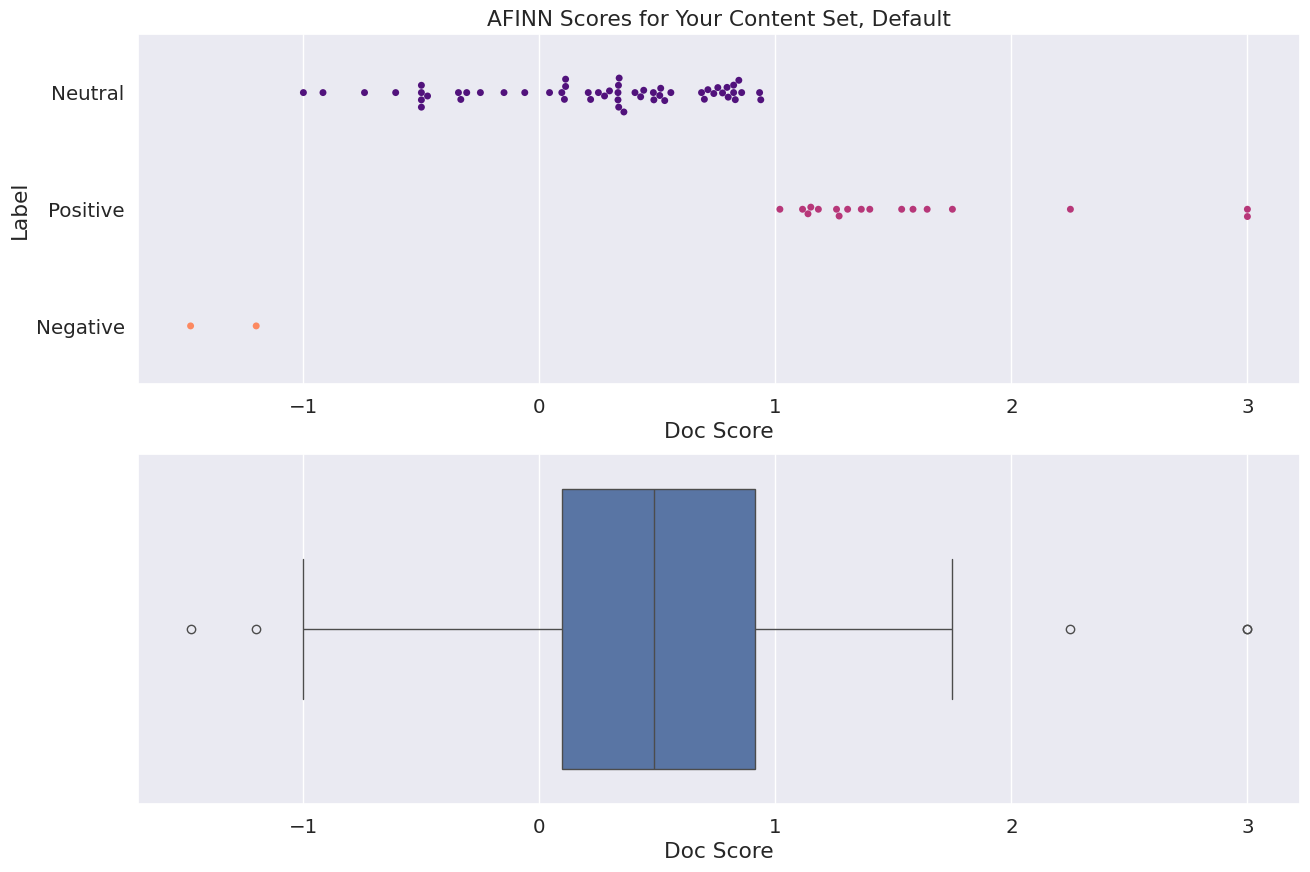

In [6]:
sns.set(font_scale=1.3) # increasing the text size so it's easier to read

# sizes the graphs nicely and creating the two spaces to graph in
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10)) 
# making the swarmplot
sns.swarmplot(ax=ax1, x="Doc Score", y="Label", hue="Label", palette="magma", data=student_afinn_df) 
# a swarmplot is a categorical scatterplot with points adjusted to not overlap 
# so it's easier to see the distribution
ax1.set_title('AFINN Scores for Your Content Set, Default') # adding a title to the graph

sns.boxplot(ax=ax2, x=student_afinn_df["Doc Score"]) # making the boxplot
print() # printing blank line to remove weird '<Axes.subplot> text

In [7]:
# you can use this to look at individuaL document scores if you want!

# tool to look at any rows that contain search term in file name, case insensitive, sorted alphabetically
# note that spaces do not work - words must be separated by underscores (_) as they would be in the file names

search_term = '' # change the text within the ''s and then run code block to search for a different term
student_afinn_df[student_afinn_df['File'].str.contains(search_term, case=False)].sort_values('File')

,File,Total Score,Num Scored Tokens,Doc Score,Label
73,'ere_round_the_huge__CW0113350932.txt,1.0,3,0.333,Neutral
72,A_Collection_of_Engl_CB0129583847.txt,1826.0,2219,0.823,Neutral
71,"A_Loyal_song,_CB0130523337.txt",30.0,22,1.364,Positive
70,A_New_ballad._The_bo_CB0127690334.txt,18.0,6,3.000,Positive
69,"A_New_song,_called_t_CB0130523365.txt",-14.0,23,-0.609,Neutral
...,...,...,...,...,...
4,The_valiant_dragoo'n_CW0116745543.txt,-8.0,16,-0.500,Neutral
3,The_waggoner._Sung_b_CW0117136903.txt,-3.0,9,-0.333,Neutral
2,Tom_Tackle._Sung_by__CB0130523325.txt,6.0,24,0.250,Neutral
1,"Tom_Tough;_or,_yo_he_CW0117136907.txt",15.0,16,0.938,Neutral


What do you see? Does anything surprise you? How similar or different is this analysis to the one you get from the Lab?

### VADER

In [8]:
analyser = SentimentIntensityAnalyzer() # instantiating the tool

scores = [] # a list to keep track of the documents
for doc in documents: # go through each document in the list we made when working with AFINN
    # appending the document name to the directory name so we can find the file
    filename = str(directory + '/' + doc) 
    
    # lets us access the actual text inside the file
    with open(filename) as f:
        # gets all of the text from the file and brings it over so we can work with it
        contents = f.read()
        # scores the file's text
        score_dict = analyser.polarity_scores(contents)
        # adds that score to the list so we use the scores later
        scores.append(score_dict)

#----------------#
# extracting each score type into a list
#----------------#
neg_list = []
neu_list = []
pos_list = []
compound_list = []
# How are scores organized?
for d in scores:
    neg_list.append(d['neg'])
    neu_list.append(d['neu'])
    pos_list.append(d['pos'])
    compound_list.append(d['compound'])

#----------------#
# labeling the documents based on their compound score
# What would be an appropriate threshold for each label?
#----------------#
labels = []
for score in compound_list:
    if score > 0.1:
        labels.append('Positive')
    elif score < -0.1:
        labels.append('Negative')
    else:
        labels.append('Neutral')

table_data = list(zip(documents, neg_list, neu_list, pos_list, compound_list, labels)) # combining all lists
student_vader_df = pd.DataFrame(table_data, columns=['File', 'Percent Negative', 'Percent Neutral', 'Percent Positive',
                                             'Overall Score', 'Label']) # creating the table
student_vader_df # displaying the table

,File,Percent Negative,Percent Neutral,Percent Positive,Overall Score,Label
0,Walter_and_William.__CW0115639198.txt,0.170,0.754,0.076,-0.9986,Negative
1,"Tom_Tough;_or,_yo_he_CW0117136907.txt",0.088,0.770,0.142,0.9325,Positive
2,Tom_Tackle._Sung_by__CB0130523325.txt,0.113,0.683,0.205,0.9842,Positive
3,The_waggoner._Sung_b_CW0117136903.txt,0.074,0.853,0.072,0.1363,Positive
4,The_valiant_dragoo'n_CW0116745543.txt,0.147,0.652,0.200,0.9062,Positive
...,...,...,...,...,...,...
69,"A_New_song,_called_t_CB0130523365.txt",0.285,0.455,0.260,-0.3254,Negative
70,A_New_ballad._The_bo_CB0127690334.txt,0.000,0.899,0.101,0.9614,Positive
71,"A_Loyal_song,_CB0130523337.txt",0.058,0.629,0.313,0.9948,Positive
72,A_Collection_of_Engl_CB0129583847.txt,0.116,0.577,0.307,1.0000,Positive


In [9]:
print("Sentiment Label Counts - VADER")
# list of unique values for column and number of times each appeared
print(student_vader_df['Label'].value_counts()) 

Sentiment Label Counts - VADER
Label
Positive    65
Negative     9
Name: count, dtype: int64


/opt/conda/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


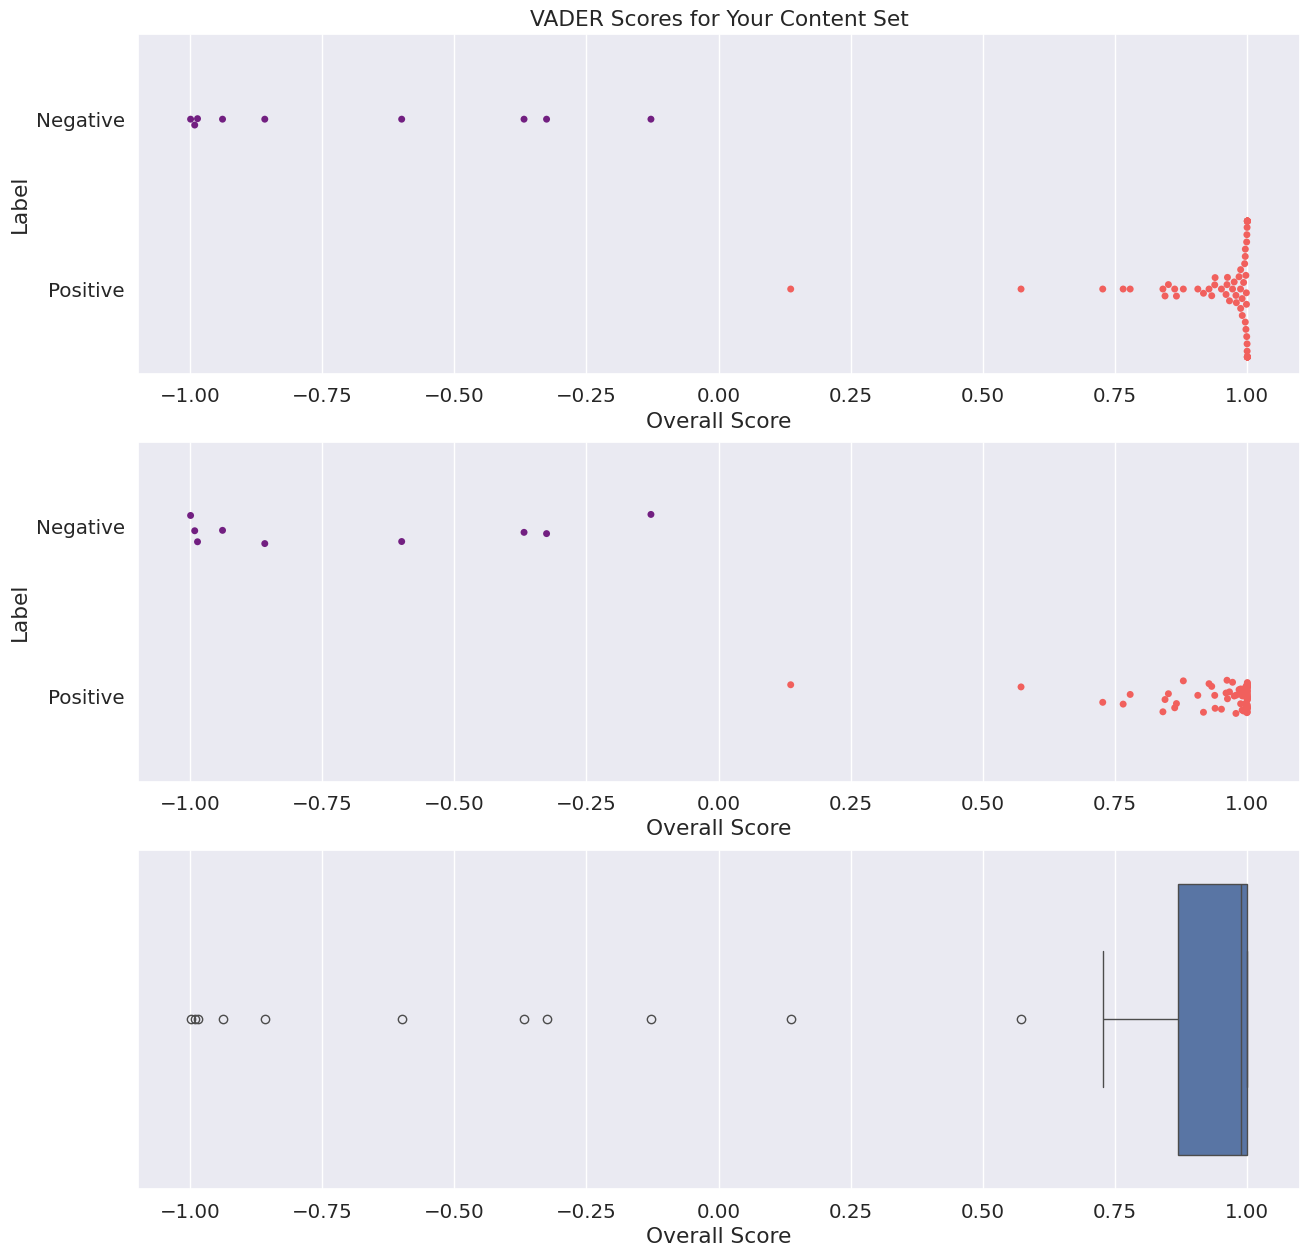

In [11]:
sns.set(font_scale=1.3) # increasing the text size so it's easier to read

#----------------#
# Creating the swarmplot for the data
#----------------#
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 15))
sns.swarmplot(ax=ax1, x="Overall Score", y="Label", hue="Label", palette="magma", data=student_vader_df)
ax1.set_title('VADER Scores for Your Content Set')

# a striplot is a categorical scatterplot with jitter added to reduce overlap 
# so it's easier to see the distribution
# included again to show what Python recommends and what we would choose to do
sns.stripplot(ax=ax2, x="Overall Score", y="Label", hue="Label", palette="magma", data=student_vader_df)

sns.boxplot(ax=ax3, x=student_vader_df["Overall Score"]) # making the boxplot

print() # printing blank line to remove weird '<Axes.subplot> text

In [12]:
# you can use this to look at individual document scores if you want.

# tool to look at any rows that contain search term in file name, case insensitive, sorted alphabetically
# note that spaces do not work - words must be separated by underscores (_) as they would be in the file names

search_term = '' # change the text within the ''s and then run code block to search for a different term
student_vader_df[student_vader_df['File'].str.contains(search_term, case=False)].sort_values('File')

,File,Percent Negative,Percent Neutral,Percent Positive,Overall Score,Label
73,'ere_round_the_huge__CW0113350932.txt,0.000,0.890,0.110,0.8442,Positive
72,A_Collection_of_Engl_CB0129583847.txt,0.116,0.577,0.307,1.0000,Positive
71,"A_Loyal_song,_CB0130523337.txt",0.058,0.629,0.313,0.9948,Positive
70,A_New_ballad._The_bo_CB0127690334.txt,0.000,0.899,0.101,0.9614,Positive
69,"A_New_song,_called_t_CB0130523365.txt",0.285,0.455,0.260,-0.3254,Negative
...,...,...,...,...,...,...
4,The_valiant_dragoo'n_CW0116745543.txt,0.147,0.652,0.200,0.9062,Positive
3,The_waggoner._Sung_b_CW0117136903.txt,0.074,0.853,0.072,0.1363,Positive
2,Tom_Tackle._Sung_by__CB0130523325.txt,0.113,0.683,0.205,0.9842,Positive
1,"Tom_Tough;_or,_yo_he_CW0117136907.txt",0.088,0.770,0.142,0.9325,Positive


What did you notice about your sentiment analysis? Did you prefer AFINN, VADER, or neither, and why? Did you learn anything about your dataset?